<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/MV_PBL_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow matplotlib numpy

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1547s 9us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


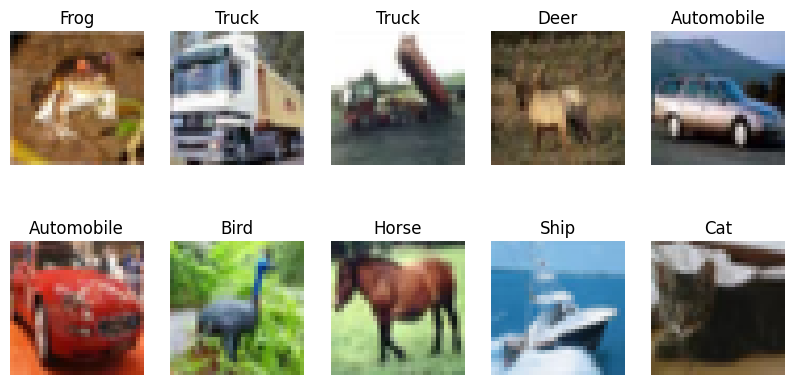

In [ ]:
classes = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")

plt.show()

In [ ]:
print("Minimum Pixel :", X_train.min())
print("Maximum Pixel :", X_train.max())

print("Image Shape :", X_train[0].shape)

print("Total Images :", len(X_train))

Minimum Pixel : 0
Maximum Pixel : 255
Image Shape : (32, 32, 3)
Total Images : 50000


In [ ]:
X_train = X_train.astype("float32")

X_train = (X_train - 127.5) / 127.5

print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

Minimum : -1.0
Maximum : 1.0


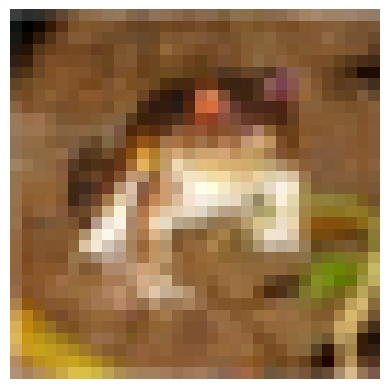

In [ ]:
plt.imshow((X_train[0] + 1) / 2)

plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Reshape, BatchNormalization
from tensorflow.keras.layers import Conv2DTranspose, LeakyReLU

def build_generator():
    model = Sequential()

    # Input: Random noise (100 values)
    model.add(Dense(4 * 4 * 256, input_dim=100))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())
    model.add(Reshape((4, 4, 256)))

    # 4x4 -> 8x8
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2,
                              padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    # 8x8 -> 16x16
    model.add(Conv2DTranspose(64, kernel_size=4, strides=2,
                              padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    # 16x16 -> 32x32
    model.add(Conv2DTranspose(3, kernel_size=4, strides=2,
                              padding='same',
                              activation='tanh'))

    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089,475 (4.16 MB)

 Trainable params: 1,080,899 (4.12 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [ ]:
noise = tf.random.normal([1, 100])

generated_image = generator(noise, training=False)

print(generated_image.shape)

(1, 32, 32, 3)


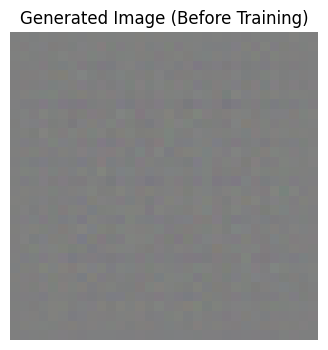

In [ ]:
plt.figure(figsize=(4,4))

plt.imshow((generated_image[0] + 1) / 2)

plt.axis("off")

plt.title("Generated Image (Before Training)")

plt.show()

In [ ]:
from tensorflow.keras.layers import Conv2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

def build_discriminator():

    model = Sequential()

    # Input: 32x32x3 image
    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same',
                     input_shape=(32,32,3)))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # 16x16
    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # 8x8
    model.add(Flatten())

    # Output
    model.add(Dense(1, activation='sigmoid'))

    return model


discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,529 (556.75 KB)

 Trainable params: 142,529 (556.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
prediction = discriminator(generated_image)

print(prediction)

tf.Tensor([[0.5007539]], shape=(1, 1), dtype=float32)


In [ ]:
discriminator.trainable = False

In [ ]:
gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

gan.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │     1,089,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       142,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,232,004 (4.70 MB)

 Trainable params: 1,080,899 (4.12 MB)

 Non-trainable params: 151,105 (590.25 KB)